<a href="https://colab.research.google.com/github/EcTrailblazers/python-data-projects/blob/main/05_state_scheme_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

raw_scheme_data = """State,Funds_Allocated_Cr,Funds_Utilized_Cr,Total_Workdays_Lakh,Women_Workdays_Lakh
Andhra Pradesh,4850.0,4720.5,2450.0,1420.0
Telangana,3200.0,2980.0,1580.0,980.0
Tamil Nadu,5100.0,5050.0,2800.0,2380.0
Karnataka,4100.0,3650.0,1850.0,925.0
Maharashtra,3900.0,3120.0,1400.0,630.0
Uttar Pradesh,7200.0,6100.0,3100.0,1116.0
Bihar,5800.0,4350.0,2200.0,880.0
Rajasthan,6400.0,6200.0,2950.0,1976.5
Madhya Pradesh,4900.0,4410.0,2100.0,882.0
West Bengal,4500.0,2250.0,1200.0,540.0
"""

with open("state_scheme_data.csv", "w") as f:
    f.write(raw_scheme_data.strip())

print("state_scheme_data.csv created successfully.")

state_scheme_data.csv created successfully.


In [2]:
df_scheme = pd.read_csv("state_scheme_data.csv")

# 1. Calculate Fund Utilization Rate (%)
df_scheme["Utilization_Rate"] = (
    df_scheme["Funds_Utilized_Cr"] / df_scheme["Funds_Allocated_Cr"]
) * 100

# 2. Calculate Women Participation Rate (%)
df_scheme["Women_Participation_Rate"] = (
    df_scheme["Women_Workdays_Lakh"] / df_scheme["Total_Workdays_Lakh"]
) * 100

# 3. Derive Unspent Funds (in ₹ Crores)
df_scheme["Unspent_Funds_Cr"] = (
    df_scheme["Funds_Allocated_Cr"] - df_scheme["Funds_Utilized_Cr"]
)

# 4. Classify performance tiers by utilization efficiency
df_scheme["Efficiency_Tier"] = np.where(
    df_scheme["Utilization_Rate"] >= 90.0,
    "High",
    np.where(df_scheme["Utilization_Rate"] >= 75.0, "Moderate", "Lagging"),
)

# Sort descending by utilization performance
df_scheme = df_scheme.sort_values(
    by="Utilization_Rate", ascending=False
).reset_index(drop=True)

print("--- State Governance Performance Audit ---")
print(
    df_scheme[
        [
            "State",
            "Utilization_Rate",
            "Women_Participation_Rate",
            "Unspent_Funds_Cr",
            "Efficiency_Tier",
        ]
    ]
)

--- State Governance Performance Audit ---
            State  Utilization_Rate  Women_Participation_Rate  \
0      Tamil Nadu         99.019608                 85.000000   
1  Andhra Pradesh         97.329897                 57.959184   
2       Rajasthan         96.875000                 67.000000   
3       Telangana         93.125000                 62.025316   
4  Madhya Pradesh         90.000000                 42.000000   
5       Karnataka         89.024390                 50.000000   
6   Uttar Pradesh         84.722222                 36.000000   
7     Maharashtra         80.000000                 45.000000   
8           Bihar         75.000000                 40.000000   
9     West Bengal         50.000000                 45.000000   

   Unspent_Funds_Cr Efficiency_Tier  
0              50.0            High  
1             129.5            High  
2             200.0            High  
3             220.0            High  
4             490.0            High  
5            

In [3]:
# National aggregate totals
total_allocated = df_scheme["Funds_Allocated_Cr"].sum()
total_utilized = df_scheme["Funds_Utilized_Cr"].sum()
overall_utilization = (total_utilized / total_allocated) * 100

total_workdays = df_scheme["Total_Workdays_Lakh"].sum()
total_women_workdays = df_scheme["Women_Workdays_Lakh"].sum()
national_women_rate = (total_women_workdays / total_workdays) * 100

print(f"Total National Allocation: ₹{total_allocated:,.1f} Cr")
print(f"Total National Spend:      ₹{total_utilized:,.1f} Cr")
print(f"Aggregate Utilization:     {overall_utilization:.2f}%\n")
print(
    f"National Women Participation: {national_women_rate:.2f}% (Statutory baseline: 33.33%)"
)

# Identify benchmark extremes
top_state = df_scheme.iloc[0]
lagging_state = df_scheme.iloc[-1]
print(
    f"Highest Utilization: {top_state['State']} ({top_state['Utilization_Rate']:.1f}%)"
)
print(
    f"Lowest Utilization:  {lagging_state['State']} ({lagging_state['Utilization_Rate']:.1f}%)"
)

Total National Allocation: ₹49,950.0 Cr
Total National Spend:      ₹42,830.5 Cr
Aggregate Utilization:     85.75%

National Women Participation: 54.23% (Statutory baseline: 33.33%)
Highest Utilization: Tamil Nadu (99.0%)
Lowest Utilization:  West Bengal (50.0%)


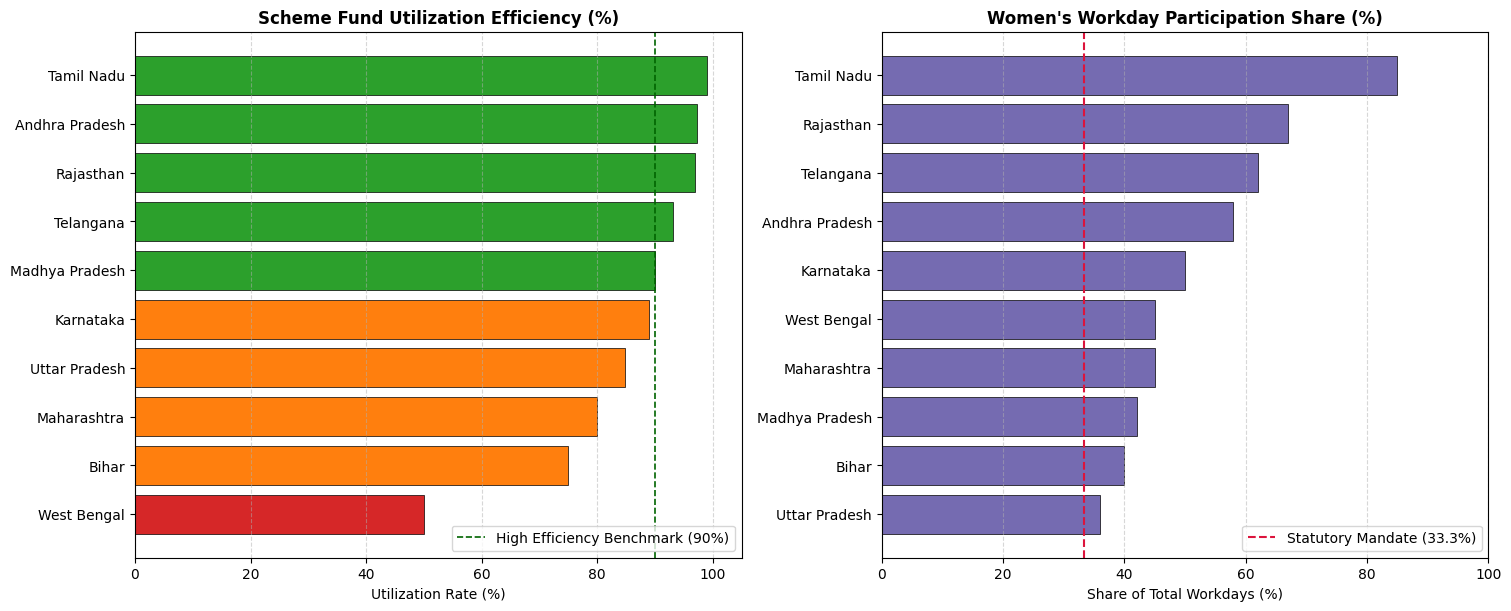

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), layout="constrained")

# --- Chart 1: Fund Utilization Efficiency by State ---
utilization_sorted = df_scheme.sort_values(by="Utilization_Rate")
colors = [
    "#2ca02c"
    if tier == "High"
    else ("#ff7f0e" if tier == "Moderate" else "#d62728")
    for tier in utilization_sorted["Efficiency_Tier"]
]

ax1.barh(
    utilization_sorted["State"],
    utilization_sorted["Utilization_Rate"],
    color=colors,
    edgecolor="black",
    linewidth=0.5,
)
ax1.axvline(
    90.0,
    color="darkgreen",
    linestyle="--",
    linewidth=1.2,
    label="High Efficiency Benchmark (90%)",
)
ax1.set_title(
    "Scheme Fund Utilization Efficiency (%)", fontsize=12, weight="bold"
)
ax1.set_xlabel("Utilization Rate (%)")
ax1.set_xlim(0, 105)
ax1.legend(loc="lower right")
ax1.grid(axis="x", linestyle="--", alpha=0.5)

# --- Chart 2: Women Participation vs Statutory Mandate ---
women_sorted = df_scheme.sort_values(by="Women_Participation_Rate")
ax2.barh(
    women_sorted["State"],
    women_sorted["Women_Participation_Rate"],
    color="#756bb1",
    edgecolor="black",
    linewidth=0.5,
)
ax2.axvline(
    33.33,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label="Statutory Mandate (33.3%)",
)
ax2.set_title(
    "Women's Workday Participation Share (%)", fontsize=12, weight="bold"
)
ax2.set_xlabel("Share of Total Workdays (%)")
ax2.set_xlim(0, 100)
ax2.legend(loc="lower right")
ax2.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()